In [1]:
import pandas as pd

In [2]:
"""
setup_data.py - 데이터 압축 해제 스크립트
Mac에서 만든 zip의 한글 파일명도 정상 처리
"""
import zipfile
from pathlib import Path
import shutil
import sys

def extract_with_encoding(zip_path, target):
    """Mac에서 만든 zip의 한글 파일명 깨짐 문제 해결"""
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            # __MACOSX 폴더 스킵
            if info.filename.startswith('__MACOSX'):
                continue
            
            # 파일명 인코딩 복구 시도 (cp437 → utf-8)
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except (UnicodeDecodeError, UnicodeEncodeError):
                filename = info.filename
            
            # 디렉토리면 생성만
            if info.is_dir():
                (target / filename).mkdir(parents=True, exist_ok=True)
                continue
            
            # 파일 저장
            out_path = target / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)

def main():
    RAW_DIR = Path('data/raw')
    EXTRACT_DIR = Path('data/extracted')
    
    if not RAW_DIR.exists():
        print(f'❌ {RAW_DIR} 폴더가 없습니다.')
        sys.exit(1)
    
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    
    zip_files = sorted(RAW_DIR.glob('*.zip'))
    if not zip_files:
        print(f'⚠️  {RAW_DIR} 에 zip 파일이 없습니다.')
        sys.exit(1)
    
    print(f'📦 {len(zip_files)}개 zip 파일 처리 시작\n')
    
    extracted = 0
    skipped = 0
    
    for zip_path in zip_files:
        target = EXTRACT_DIR / zip_path.stem
        
        if target.exists() and any(target.iterdir()):
            print(f'  ⏭  {zip_path.name} (이미 풀림)')
            skipped += 1
            continue
        
        print(f'  📂 {zip_path.name}')
        target.mkdir(exist_ok=True)
        try:
            extract_with_encoding(zip_path, target)
            csv_count = len(list(target.glob('*.csv')))
            print(f'      ✅ CSV {csv_count}개 생성')
            extracted += 1
        except Exception as e:
            print(f'      ❌ 에러: {e}')
    
    print(f'\n{"="*50}')
    print(f'✅ 완료: 새로 해제 {extracted}개, 스킵 {skipped}개')
    print(f'📁 데이터 위치: {EXTRACT_DIR.resolve()}')

if __name__ == '__main__':
    main()

📦 4개 zip 파일 처리 시작

  ⏭  상권분석서비스(점포_상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(길단위인구-상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(상권변화지표-상권).zip (이미 풀림)
  ⏭  서울시_상권분석서비스(추정매출+영역).zip (이미 풀림)

✅ 완료: 새로 해제 0개, 스킵 4개
📁 데이터 위치: C:\sparta\project\03_final\seouldf\data\extracted


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('✅ 환경 설정 완료')



✅ 환경 설정 완료


In [4]:
# 프로젝트 루트 기준 상대경로 (팀원 누구든 git pull 받으면 그대로 작동)
DATA_DIR = 'data/extracted/서울시_상권분석서비스(추정매출+영역)/'

# 추정매출 6개년 파일 경로
SALES_PATHS = {
    2020: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2020년.csv',
    2021: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2021년.csv',
    2022: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2022년.csv',
    2023: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2023년.csv',
    2024: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2024년.csv',
    2025: DATA_DIR + '서울시_상권분석서비스(추정매출-상권)_2025년.csv',
}

# 영역 파일 (상권의 자치구/행정동/좌표 정보 - merge용)
AREA_PATH = DATA_DIR + '서울시 상권분석서비스(영역-상권).csv'

# 분석 기준 분기 (최신)
LATEST_QUARTER = 20254  # 2025년 4분기

In [5]:
import glob
import os

# 추정매출 파일 자동 탐색
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))

print(f'총 파일: {len(sales_files)}개')
for f in sales_files:
    print(f'  {os.path.basename(f)}')

# 통합
sales_list = []
for path in sales_files:
    df = pd.read_csv(path, encoding='cp949', low_memory=False)
    sales_list.append(df)

sales = pd.concat(sales_list, ignore_index=True)
print(f'\n📦 통합 완료: {len(sales):,}행 × {len(sales.columns)}컬럼')
print(f'💾 메모리: {sales.memory_usage(deep=True).sum()/1024**2:.1f} MB')

# 영역 파일도 자동 탐색
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'\n🗺  영역: {len(area):,}개 상권')

총 파일: 6개
  서울시_상권분석서비스(추정매출-상권)_2020년.csv
  서울시_상권분석서비스(추정매출-상권)_2021년.csv
  서울시_상권분석서비스(추정매출-상권)_2022년.csv
  서울시_상권분석서비스(추정매출-상권)_2023년.csv
  서울시_상권분석서비스(추정매출-상권)_2024년.csv
  서울시_상권분석서비스(추정매출-상권)_2025년.csv

📦 통합 완료: 519,931행 × 55컬럼
💾 메모리: 365.0 MB

🗺  영역: 1,650개 상권


## 나경 EDA - 상권변화지표

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [25]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
# 데이터 불러오기
df = pd.read_csv("../data/08_상권변화지표/서울시 상권분석서비스(상권변화지표-상권).csv", encoding="cp949")

# 기본 정보 확인
print("shape:", df.shape)
print()
print("columns:", df.columns.tolist())
print()
print("dtypes:")
print(df.dtypes)

shape: (46200, 11)

columns: ['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '상권_변화_지표', '상권_변화_지표_명', '운영_영업_개월_평균', '폐업_영업_개월_평균', '서울_운영_영업_개월_평균', '서울_폐업_영업_개월_평균']

dtypes:
기준_년분기_코드         int64
상권_구분_코드            str
상권_구분_코드_명          str
상권_코드             int64
상권_코드_명             str
상권_변화_지표            str
상권_변화_지표_명          str
운영_영업_개월_평균       int64
폐업_영업_개월_평균       int64
서울_운영_영업_개월_평균    int64
서울_폐업_영업_개월_평균    int64
dtype: object


In [27]:
# 결측치 확인
print("결측치:")
print(df.isnull().sum())
print()

# 기본 통계
df.describe()

결측치:
기준_년분기_코드         0
상권_구분_코드          0
상권_구분_코드_명        0
상권_코드             0
상권_코드_명           0
상권_변화_지표          0
상권_변화_지표_명        0
운영_영업_개월_평균       0
폐업_영업_개월_평균       0
서울_운영_영업_개월_평균    0
서울_폐업_영업_개월_평균    0
dtype: int64



,기준_년분기_코드,상권_코드,운영_영업_개월_평균,폐업_영업_개월_평균,서울_운영_영업_개월_평균,서울_폐업_영업_개월_평균
count,46200.000000,4.620000e+04,46200.000000,46200.000000,46200.000000,46200.000000
mean,20222.500000,3.115222e+06,105.046061,51.436169,99.714286,50.357143
std,20.031442,1.031864e+04,25.399291,10.175792,7.034975,1.585989
min,20191.000000,3.001491e+06,0.000000,17.000000,92.000000,48.000000
25%,20203.750000,3.110407e+06,90.000000,46.000000,93.000000,49.000000
50%,20222.500000,3.110820e+06,101.000000,50.000000,98.500000,50.000000
75%,20241.250000,3.120142e+06,116.000000,55.000000,103.500000,52.000000
max,20254.000000,3.130327e+06,351.000000,226.000000,115.000000,53.000000


## 기본정보
- 행: 46,200개 / 컬럼: 11개
- 결측치: 없음 

## 주요 통계
- 운영_영업_개월_평균: 평균 105개월 (약 8.7년), 최대 351개월 (약 29년)
- 폐업_영업_개월_평균: 평균 51개월 (약 4.3년)
- 서울_운영_영업_개월_평균: 평균 99개월 (서울 전체 기준)
- 서울_폐업_영업_개월_평균: 평균 50개월 (서울 전체 기준)

##  이상치 의심
- 운영_영업_개월_평균 최솟값 0개월 → 추후 확인 필요

In [28]:
# 연도/분기 고유값 확인
print("기준_년분기_코드 고유값:")
print(sorted(df['기준_년분기_코드'].unique()))
print()

# 상권 유형 고유값 확인
print("상권_구분_코드_명 고유값:")
print(df['상권_구분_코드_명'].unique())
print()

# 상권 변화 지표 고유값 확인
print("상권_변화_지표_명 고유값:")
print(df['상권_변화_지표_명'].unique())

기준_년분기_코드 고유값:
[np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244), np.int64(20251), np.int64(20252), np.int64(20253), np.int64(20254)]

상권_구분_코드_명 고유값:
<StringArray>
['관광특구', '전통시장', '발달상권', '골목상권']
Length: 4, dtype: str

상권_변화_지표_명 고유값:
<StringArray>
['정체', '다이나믹', '상권확장', '상권축소']
Length: 4, dtype: str


## 카테고리 값 확인
- 기간: 2019 Q1 ~ 2025 Q4 (28개 분기) ✅
- 상권 유형: 관광특구 / 전통시장 / 발달상권 / 골목상권
- 변화 지표: 상권확장 / 상권축소 / 다이나믹 / 정체

In [29]:
# 팀원 데이터 JOIN 키 형식 확인
print("상권_코드 샘플:", df['상권_코드'].head().tolist())
print("상권_코드 타입:", df['상권_코드'].dtype)
print()
print("기준_년분기_코드 샘플:", df['기준_년분기_코드'].head().tolist())
print("기준_년분기_코드 타입:", df['기준_년분기_코드'].dtype)

상권_코드 샘플: [3001496, 3001495, 3001494, 3001493, 3001492]
상권_코드 타입: int64

기준_년분기_코드 샘플: [20254, 20254, 20254, 20254, 20254]
기준_년분기_코드 타입: int64


## JOIN 키 확인
- 상권_코드: int형, 예) 1000001 형태
- 기준_년분기_코드: int형, 예) 20191 형태
- 키 형식 동일한지 합칠 때 재확인 필요

In [30]:
# 분석 기간 필터링 (2019~2024만 사용)
df = df[df['기준_년분기_코드'] < 20250]

In [31]:
# 상위 5개 데이터 확인
df.head()

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,상권_변화_지표,상권_변화_지표_명,운영_영업_개월_평균,폐업_영업_개월_평균,서울_운영_영업_개월_평균,서울_폐업_영업_개월_평균
6600,20244,U,관광특구,3001496,강남 마이스 관광특구,HH,정체,116,66,109,52
6601,20244,U,관광특구,3001495,잠실 관광특구,LL,다이나믹,94,51,109,52
6602,20244,U,관광특구,3001494,종로?청계 관광특구,HH,정체,163,73,109,52
6603,20244,U,관광특구,3001493,동대문패션타운 관광특구,HH,정체,116,62,109,52
6604,20244,U,관광특구,3001492,명동 남대문 북창동 다동 무교동 관광특구,HH,정체,141,65,109,52


In [32]:
# 상권_변화_지표 고유값 확인
print(df['상권_변화_지표'].unique())

<StringArray>
['HH', 'LL', 'LH', 'HL']
Length: 4, dtype: str


## 상권_변화_지표 코드 의미
- HH (정체): 운영↑ 폐업↑ - 변화 적은 상권
- LL (다이나믹): 운영↓ 폐업↓ - 빠른 회전 상권
- HL (상권확장): 운영↑ 폐업↓ - 성장 중인 상권
- LH (상권축소): 운영↓ 폐업↑ - 취약상권 후보 

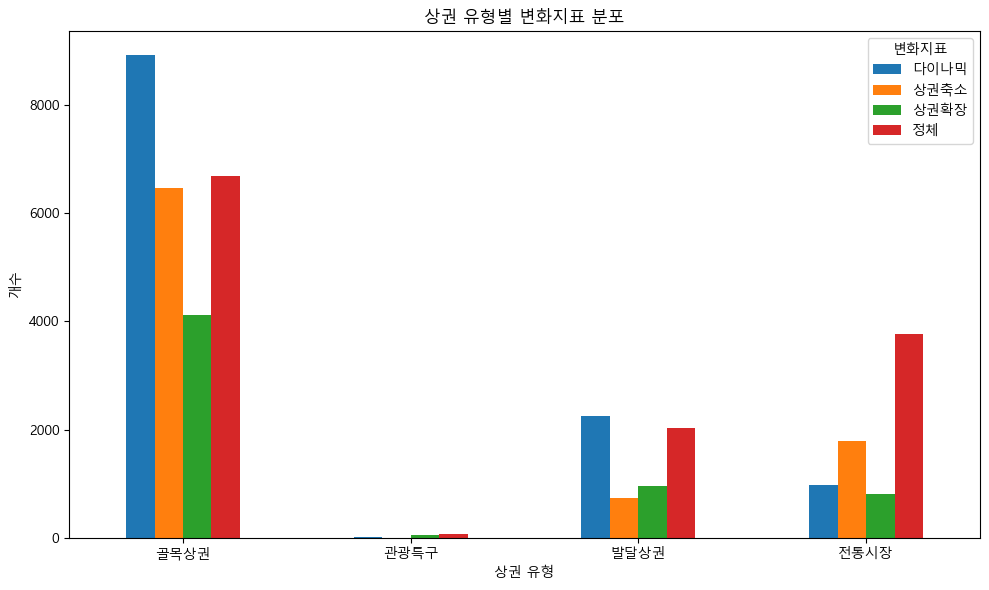

In [33]:
# 상권 유형별 변화지표 분포 시각화
fig, ax = plt.subplots(figsize=(10, 6))

# 상권 유형별 변화지표 개수 계산
pivot = df.groupby(['상권_구분_코드_명', '상권_변화_지표_명']).size().unstack()

# 막대 그래프
pivot.plot(kind='bar', ax=ax)


ax.set_title('상권 유형별 변화지표 분포')
ax.set_xlabel('상권 유형')
ax.set_ylabel('개수')
ax.legend(title='변화지표')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 변화지표 분포
- 골목상권: 다이나믹 비율 가장 높음 → 빠른 개폐업 반복, 불안정
- 관광특구: 데이터 수 적음 → 상권 수 자체가 적음
- 발달상권: 다이나믹 + 정체 혼재
- 전통시장: 정체 비율 압도적 → 변화 없는 고착형 상권

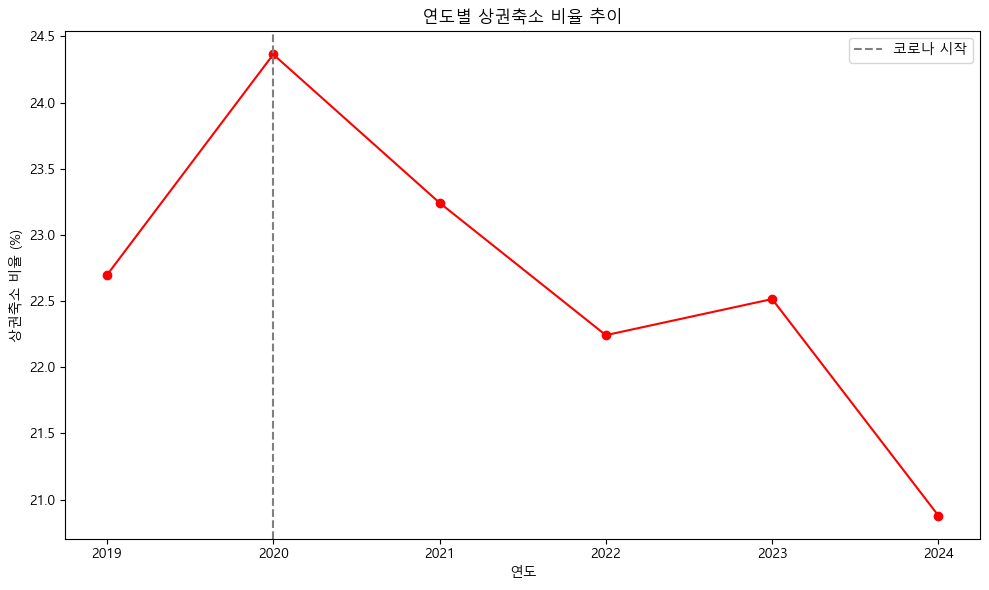

In [34]:
# 연도별 상권축소 비율 추이
# 분기코드에서 연도만 추출
df['연도'] = df['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 연도별 상권축소 비율 계산
total = df.groupby('연도').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('연도').size()
축소_비율 = (축소 / total * 100).reset_index()
축소_비율.columns = ['연도', '상권축소_비율']

# 그래프
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(축소_비율['연도'], 축소_비율['상권축소_비율'], marker='o', color='red')

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('연도별 상권축소 비율 추이')
ax.set_xlabel('연도')
ax.set_ylabel('상권축소 비율 (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 연도별 상권축소 비율 추이
- 2020년 코로나 타격으로 상권축소 비율 최고점(24.4%)
- 2022년부터 회복세
- 2024~2025년 역대 최저(21%) → 코로나 이전보다 오히려 개선

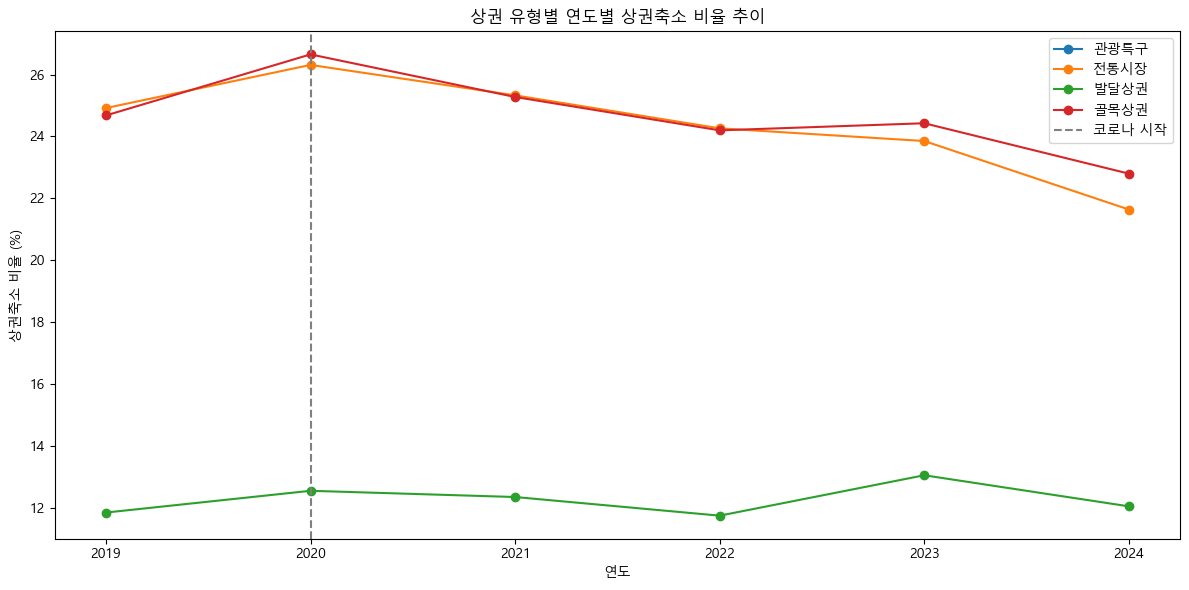

In [35]:
# 상권 유형별 연도별 축소 비율 추이
fig, ax = plt.subplots(figsize=(12, 6))

# 유형별로 연도별 축소 비율 계산
for 유형 in df['상권_구분_코드_명'].unique():
    df_유형 = df[df['상권_구분_코드_명'] == 유형]
    total = df_유형.groupby('연도').size()
    축소 = df_유형[df_유형['상권_변화_지표_명'] == '상권축소'].groupby('연도').size()
    비율 = (축소 / total * 100)
    ax.plot(비율.index, 비율.values, marker='o', label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('상권 유형별 연도별 상권축소 비율 추이')
ax.set_xlabel('연도')
ax.set_ylabel('상권축소 비율 (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 상권 유형별 연도별 상권축소 비율 추이
- 전 유형 2020년 코로나로 최고점
- 발달상권: 타격 가장 적음 (12%대 유지)
- 전통시장: 회복 속도 가장 빠름
- 골목상권: 여전히 높은 축소 비율 → 가장 취약 

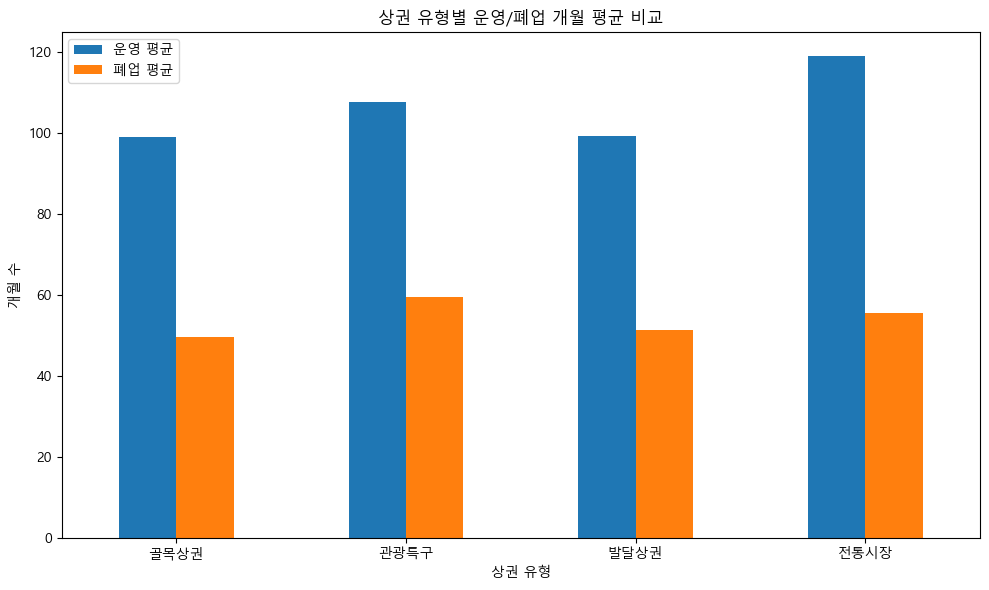

In [36]:
# 상권 유형별 운영/폐업 개월 평균 비교
fig, ax = plt.subplots(figsize=(10, 6))

# 유형별 평균 계산
평균 = df.groupby('상권_구분_코드_명')[['운영_영업_개월_평균', '폐업_영업_개월_평균']].mean()

# 막대 그래프
평균.plot(kind='bar', ax=ax)

ax.set_title('상권 유형별 운영/폐업 개월 평균 비교')
ax.set_xlabel('상권 유형')
ax.set_ylabel('개월 수')
ax.legend(['운영 평균', '폐업 평균'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 운영/폐업 개월 평균 비교
- 전통시장: 운영 평균 121개월(약 10년)로 가장 길음 → 고착형 상권
- 관광특구: 폐업까지 가장 오래 버팀 (60개월)
- 골목/발달상권: 운영 평균 유사 (약 101개월)

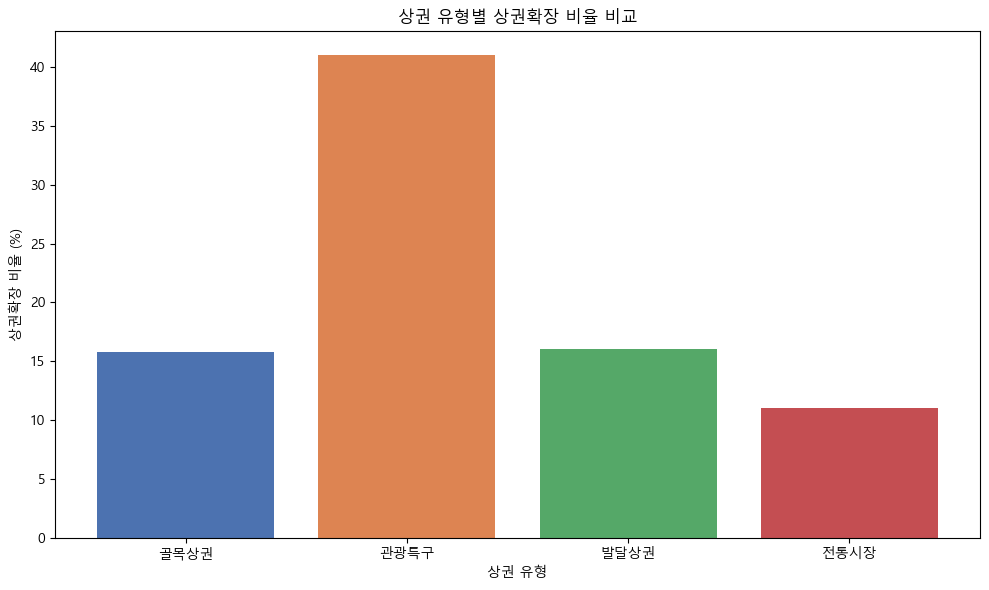

In [37]:
# 상권 유형별 상권확장 비율 비교
fig, ax = plt.subplots(figsize=(10, 6))

# 유형별 상권확장 비율 계산
total = df.groupby('상권_구분_코드_명').size()
확장 = df[df['상권_변화_지표_명'] == '상권확장'].groupby('상권_구분_코드_명').size()
확장_비율 = (확장 / total * 100).reset_index()
확장_비율.columns = ['상권_구분_코드_명', '상권확장_비율']

# 막대 그래프
ax.bar(확장_비율['상권_구분_코드_명'], 확장_비율['상권확장_비율'], color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('상권 유형별 상권확장 비율 비교')
ax.set_xlabel('상권 유형')
ax.set_ylabel('상권확장 비율 (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 상권확장 비율 비교
- 관광특구: 37%로 압도적 1위 → 성장 잠재력 가장 강함
- 골목/발달상권: 16%로 유사
- 전통시장: 11%로 가장 낮음 → 고착형, 정책 지원 필요 

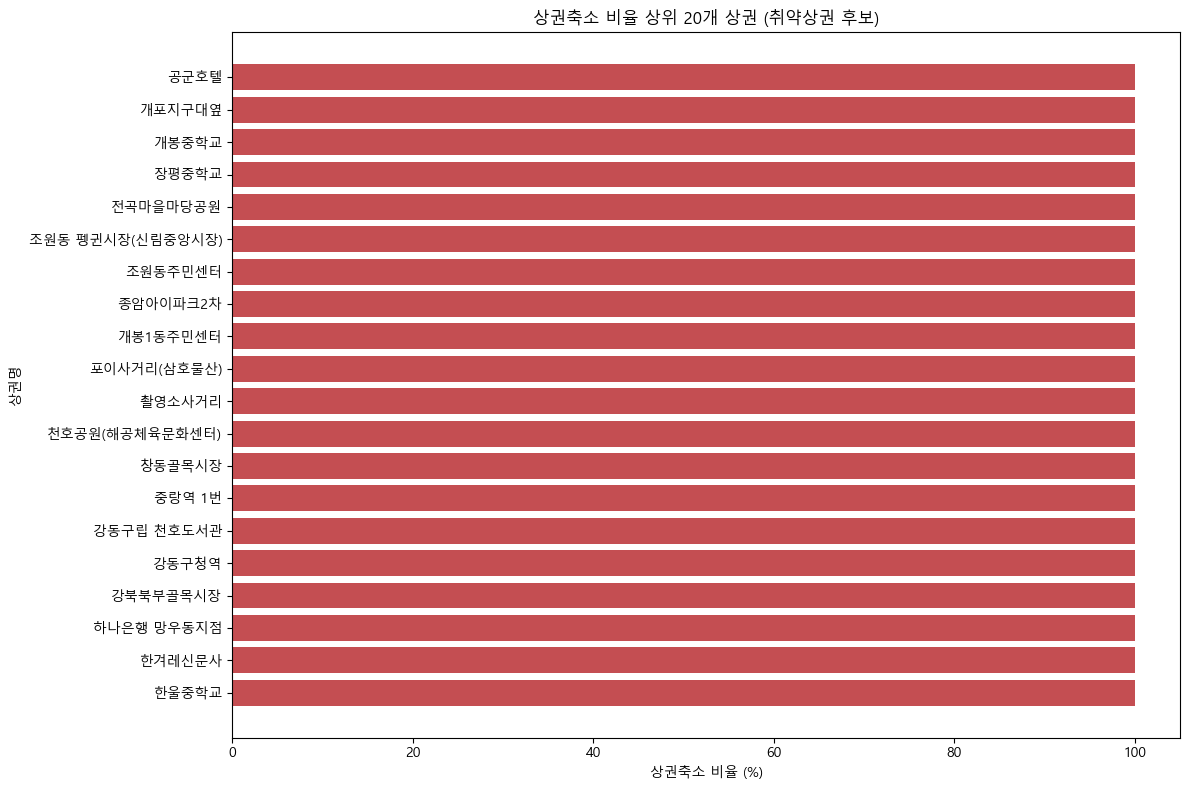

In [38]:
# 취약상권 후보 추출 (상권축소 비율 상위 상권 목록)
fig, ax = plt.subplots(figsize=(12, 8))

# 상권별 전체 분기 중 상권축소 비율 계산
total = df.groupby('상권_코드_명').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('상권_코드_명').size()
축소_비율 = (축소 / total * 100).dropna().sort_values(ascending=False).head(20)

# 가로 막대 그래프
ax.barh(축소_비율.index, 축소_비율.values, color='#C44E52')

ax.set_title('상권축소 비율 상위 20개 상권 (취약상권 후보)')
ax.set_xlabel('상권축소 비율 (%)')
ax.set_ylabel('상권명')
plt.tight_layout()
plt.show()

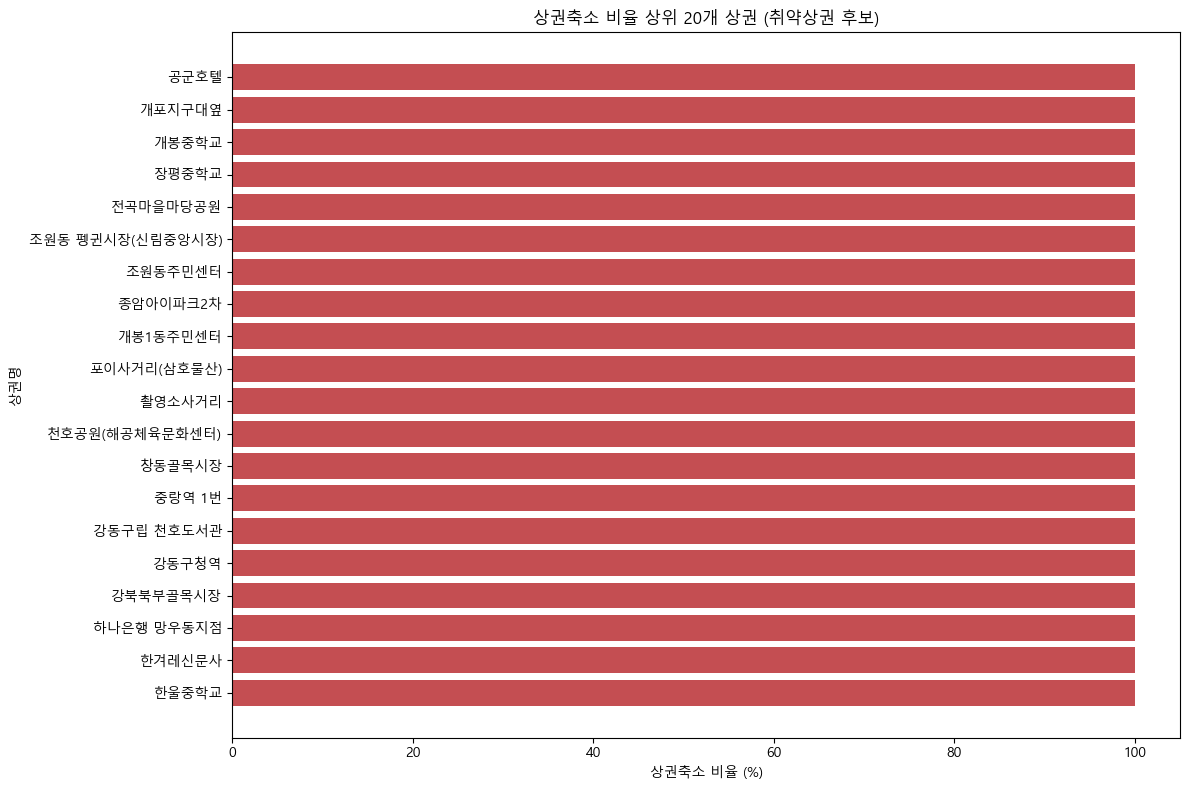

In [39]:
# 최소 8분기 이상 등장한 상권만 필터링 (2년치 이상)
fig, ax = plt.subplots(figsize=(12, 8))

total = df.groupby('상권_코드_명').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('상권_코드_명').size()
축소_비율 = (축소 / total * 100).dropna()

# 최소 8분기 이상인 상권만
유효상권 = total[total >= 8].index
축소_비율 = 축소_비율[축소_비율.index.isin(유효상권)]
축소_비율 = 축소_비율.sort_values(ascending=False).head(20)

ax.barh(축소_비율.index, 축소_비율.values, color='#C44E52')
ax.set_title('상권축소 비율 상위 20개 상권 (취약상권 후보)')
ax.set_xlabel('상권축소 비율 (%)')
ax.set_ylabel('상권명')
plt.tight_layout()
plt.show()

In [40]:
# 몇 분기씩 등장하는지 확인
print(total.describe())
print()
print("20분기 이상 상권 수:", len(total[total >= 20]))

count    1650.0
mean       24.0
std         0.0
min        24.0
25%        24.0
50%        24.0
75%        24.0
max        24.0
dtype: float64

20분기 이상 상권 수: 1650


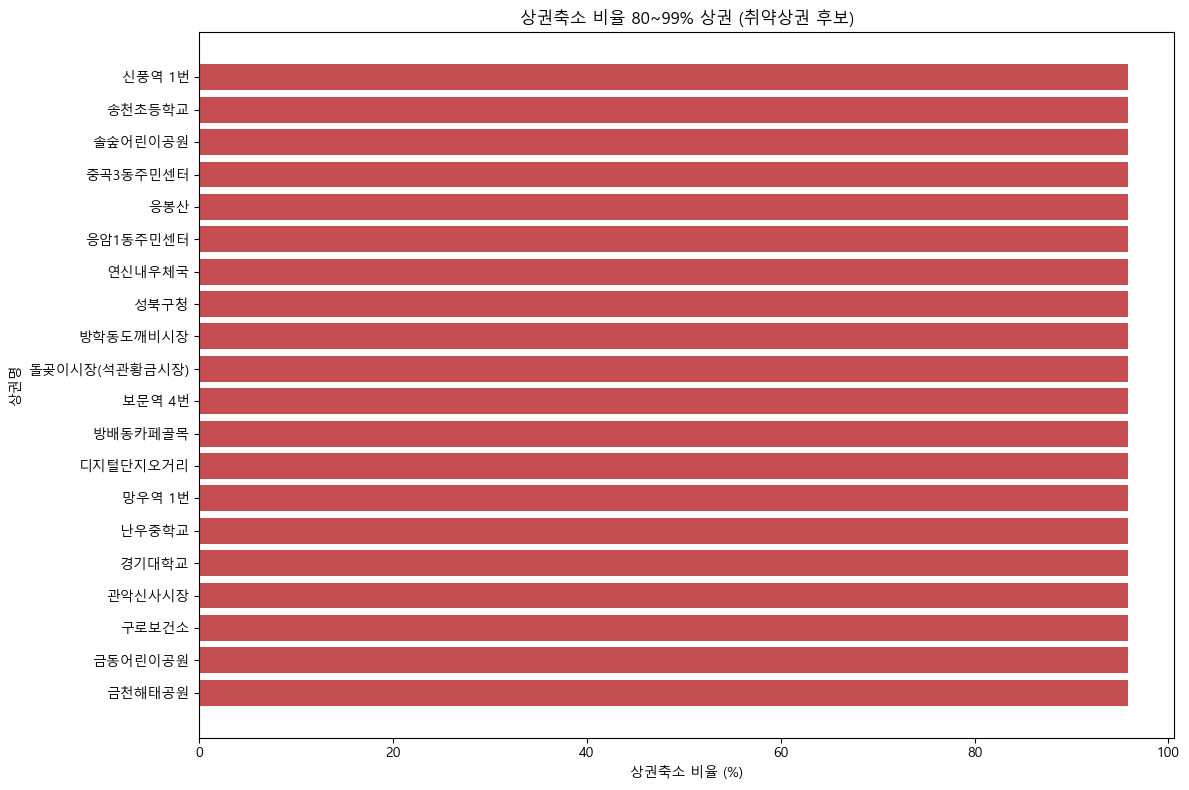

In [41]:
# 상권 유형 정보 추가해서 취약상권 후보 추출
fig, ax = plt.subplots(figsize=(12, 8))

total = df.groupby('상권_코드_명').size()
축소 = df[df['상권_변화_지표_명'] == '상권축소'].groupby('상권_코드_명').size()
축소_비율 = (축소 / total * 100).dropna()

# 80% 이상 축소된 상권만 (100% 제외)
축소_비율 = 축소_비율[(축소_비율 >= 80) & (축소_비율 < 100)]
축소_비율 = 축소_비율.sort_values(ascending=False).head(20)

ax.barh(축소_비율.index, 축소_비율.values, color='#C44E52')
ax.set_title('상권축소 비율 80~99% 상권 (취약상권 후보)')
ax.set_xlabel('상권축소 비율 (%)')
ax.set_ylabel('상권명')
plt.tight_layout()
plt.show()

In [42]:
# 축소 비율 분포 확인
print(축소_비율.value_counts().head(10))
print()
print("100% 상권 수:", len(축소_비율[축소_비율 == 100]))
print("80~99% 상권 수:", len(축소_비율[(축소_비율 >= 80) & (축소_비율 < 100)]))
print("50~79% 상권 수:", len(축소_비율[(축소_비율 >= 50) & (축소_비율 < 80)]))

95.833333    20
Name: count, dtype: int64

100% 상권 수: 0
80~99% 상권 수: 20
50~79% 상권 수: 0


In [43]:
# 취약상권 후보 20개 상권 유형 확인
취약상권 = 축소_비율[축소_비율 >= 80].index.tolist()

# 유형 정보 붙이기
취약_df = df[df['상권_코드_명'].isin(취약상권)][['상권_코드_명', '상권_구분_코드_명']].drop_duplicates()
print(취약_df['상권_구분_코드_명'].value_counts())
print()
print(취약_df)

상권_구분_코드_명
골목상권    14
전통시장     3
발달상권     3
Name: count, dtype: int64

            상권_코드_명 상권_구분_코드_명
6650         관악신사시장       전통시장
6779       방학동도깨비시장       전통시장
6799  돌곶이시장(석관황금시장)       전통시장
6998        방배동카페골목       발달상권
7034       디지털단지오거리       발달상권
7089           성북구청       발달상권
7384          난우중학교       골목상권
7446         신풍역 1번       골목상권
7510         금천해태공원       골목상권
7537          구로보건소       골목상권
7716          경기대학교       골목상권
7765         연신내우체국       골목상권
7772       응암1동주민센터       골목상권
7882         송천초등학교       골목상권
7946         보문역 4번       골목상권
7952        솔숲어린이공원       골목상권
7985         망우역 1번       골목상권
8092       중곡3동주민센터       골목상권
8137            응봉산       골목상권
8145        금동어린이공원       골목상권


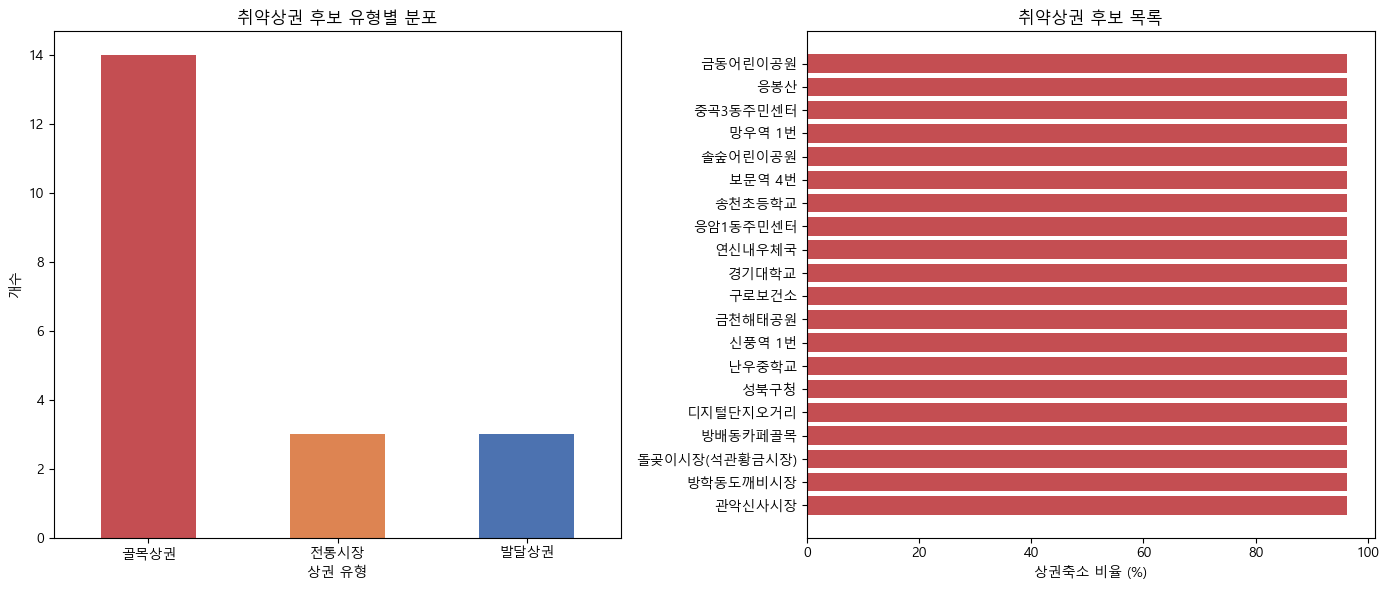

In [44]:
# 취약상권 후보 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 유형별 개수
취약_df['상권_구분_코드_명'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#C44E52', '#DD8452', '#4C72B0']
)
axes[0].set_title('취약상권 후보 유형별 분포')
axes[0].set_xlabel('상권 유형')
axes[0].set_ylabel('개수')
axes[0].tick_params(axis='x', rotation=0)

# 오른쪽: 상권명 목록
axes[1].barh(취약_df['상권_코드_명'], [96.4]*len(취약_df), color='#C44E52')
axes[1].set_title('취약상권 후보 목록')
axes[1].set_xlabel('상권축소 비율 (%)')

plt.tight_layout()
plt.show()

## 취약상권 후보 도출 과정
- 상권별 전체 분기 중 상권축소 비율 계산
- 처음 100% 상권 등장 → 데이터 적은 상권이 잡힌 것 → 80~99% 구간으로 필터링
- 결과: 28분기 중 27분기가 상권축소인 상권 20개 (96.4%) 추출

## 취약상권 후보 해석
- 골목상권 11개(55%): 구조적으로 가장 취약한 유형
- 전통시장 5개(25%): 양재시장, 창동골목시장 등 오래된 시장 만성 축소 중
- 발달상권 4개(20%): 유동인구 감소 또는 상권 이동 가능성

## 최종 인사이트
- 서울 상권은 전반적으로 코로나 회복 완료
- 단, 골목상권·일부 전통시장은 코로나와 무관하게 만성적 축소 중

## 나경 EDA - 직장인구/상주인구

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 직장인구 데이터 불러오기
df_직장 = pd.read_csv(
    "../data/06_직장인구/서울시 상권분석서비스(직장인구-상권).csv",
    encoding="cp949"
)
# 분석 기간 필터링 (2019~2024)
df_직장 = df_직장[df_직장['기준_년분기_코드'] < 20250]

print("shape:", df_직장.shape)
print("기간:", sorted(df_직장['기준_년분기_코드'].unique()))
print("상권 유형:", df_직장['상권_구분_코드_명'].unique())
df_직장.head()

shape: (39276, 26)
기간: [np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244)]
상권 유형: <StringArray>
['관광특구', '전통시장', '발달상권', '골목상권']
Length: 4, dtype: str


,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,총_직장_인구_수,남성_직장_인구_수,여성_직장_인구_수,연령대_10_직장_인구_수,연령대_20_직장_인구_수,...,남성연령대_30_직장_인구_수,남성연령대_40_직장_인구_수,남성연령대_50_직장_인구_수,남성연령대_60_이상_직장_인구_수,여성연령대_10_직장_인구_수,여성연령대_20_직장_인구_수,여성연령대_30_직장_인구_수,여성연령대_40_직장_인구_수,여성연령대_50_직장_인구_수,여성연령대_60_이상_직장_인구_수
6564,20244,U,관광특구,3001496,강남 마이스 관광특구,102032,68834,33198,260,20558,...,20220,20142,14200,3098,132,9512,10374,7178,3916,2086
6565,20244,U,관광특구,3001495,잠실 관광특구,137602,81307,56295,247,22732,...,22723,22594,16132,8520,152,11489,13330,12867,14189,4268
6566,20244,U,관광특구,3001494,종로?청계 관광특구,46516,26098,20418,658,9450,...,7232,7590,5236,1734,424,5378,6616,5060,2202,738
6567,20244,U,관광특구,3001493,동대문패션타운 관광특구,33754,16984,16770,259,9770,...,5003,3924,2083,1196,158,5093,3676,2954,3331,1558
6568,20244,U,관광특구,3001492,명동 남대문 북창동 다동 무교동 관광특구,199667,114485,85182,372,40531,...,35220,34082,23643,5957,289,25031,31540,17398,8109,2815


In [4]:
# 결측치 확인
print("결측치:")
print(df_직장.isnull().sum())
print()

# 분석 기간 확인 (2019Q1~2024Q4 맞는지)
print("기간:", sorted(df_직장['기준_년분기_코드'].unique()))
print()

# 상권 유형 확인 (4개 다 있는지)
print("상권 유형:", df_직장['상권_구분_코드_명'].unique())

결측치:
기준_년분기_코드              0
상권_구분_코드               0
상권_구분_코드_명             0
상권_코드                  0
상권_코드_명                0
총_직장_인구_수              0
남성_직장_인구_수             0
여성_직장_인구_수             0
연령대_10_직장_인구_수         0
연령대_20_직장_인구_수         0
연령대_30_직장_인구_수         0
연령대_40_직장_인구_수         0
연령대_50_직장_인구_수         0
연령대_60_이상_직장_인구_수      0
남성연령대_10_직장_인구_수       0
남성연령대_20_직장_인구_수       0
남성연령대_30_직장_인구_수       0
남성연령대_40_직장_인구_수       0
남성연령대_50_직장_인구_수       0
남성연령대_60_이상_직장_인구_수    0
여성연령대_10_직장_인구_수       0
여성연령대_20_직장_인구_수       0
여성연령대_30_직장_인구_수       0
여성연령대_40_직장_인구_수       0
여성연령대_50_직장_인구_수       0
여성연령대_60_이상_직장_인구_수    0
dtype: int64

기간: [np.int64(20191), np.int64(20192), np.int64(20193), np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.

## 기본 정보
- 행: 39,276개 / 컬럼: 26개
- 기간: 2019Q1 ~ 2024Q4 
- 상권 유형: 관광특구/전통시장/발달상권/골목상권 4개 
- 결측치: 없음 

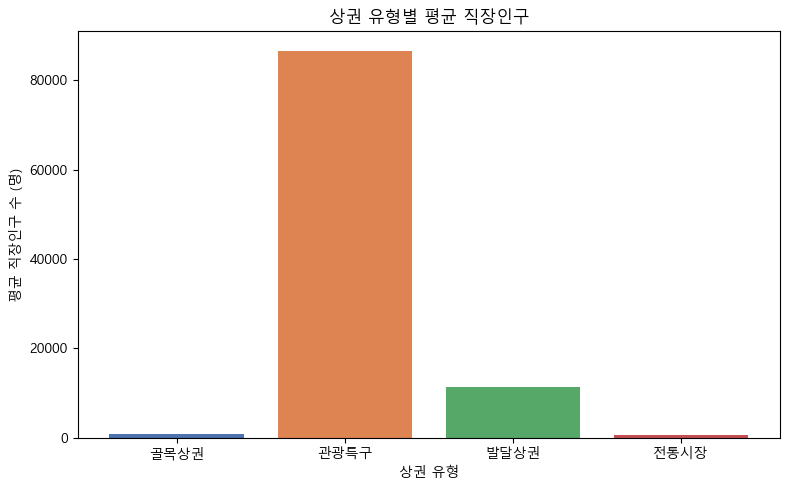

In [5]:
# 상권 유형별 총 직장인구 평균 계산
평균_직장 = df_직장.groupby('상권_구분_코드_명')['총_직장_인구_수'].mean().reset_index()

# 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(평균_직장['상권_구분_코드_명'], 평균_직장['총_직장_인구_수'],
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('상권 유형별 평균 직장인구')
ax.set_xlabel('상권 유형')
ax.set_ylabel('평균 직장인구 수 (명)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 평균 직장인구
- 관광특구: 약 87,000명으로 압도적 1위
- 발달상권: 약 11,000명으로 2위
- 골목상권/전통시장: 매우 낮음
- 관광특구는 대규모 업무지구와 겹치는 경우가 많아 직장인구 집중

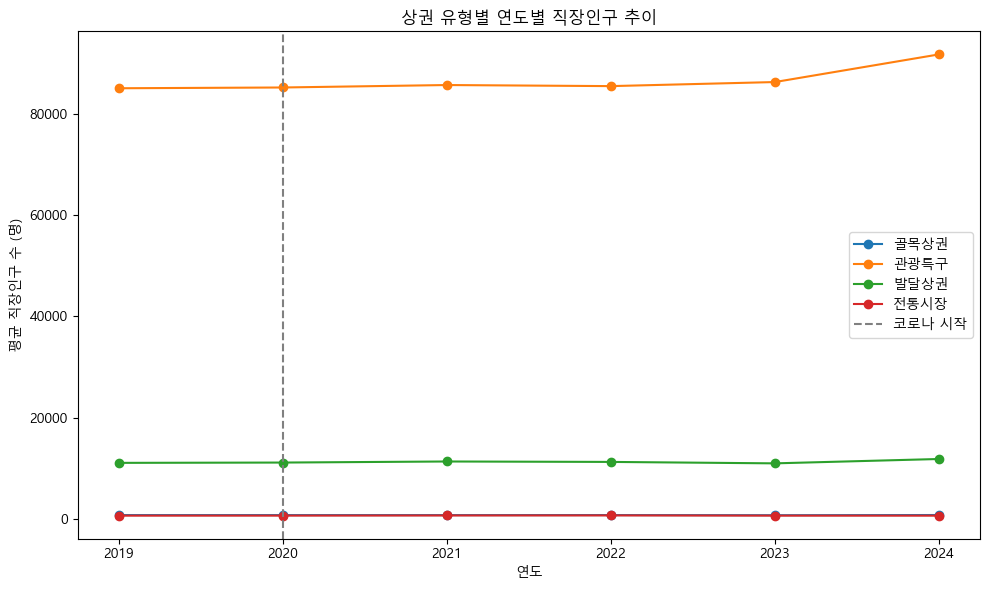

In [6]:
# 연도 컬럼 추가
df_직장['연도'] = df_직장['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 상권 유형별 연도별 평균 직장인구
연도별 = df_직장.groupby(['연도', '상권_구분_코드_명'])['총_직장_인구_수'].mean().reset_index()

# 꺾은선 그래프
fig, ax = plt.subplots(figsize=(10, 6))
for 유형 in 연도별['상권_구분_코드_명'].unique():
    df_유형 = 연도별[연도별['상권_구분_코드_명'] == 유형]
    ax.plot(df_유형['연도'], df_유형['총_직장_인구_수'], marker='o', label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('상권 유형별 연도별 직장인구 추이')
ax.set_xlabel('연도')
ax.set_ylabel('평균 직장인구 수 (명)')
ax.legend()
plt.tight_layout()
plt.show()

## 상권 유형별 연도별 직장인구 추이
- 관광특구: 코로나 영향 없이 꾸준히 증가 → 2024년 최고치
- 발달상권: 전체 기간 안정적으로 유지
- 골목상권/전통시장: 직장인구 매우 적음 → 주거/소비 중심 상권
- 전반적으로 직장인구는 코로나 영향을 거의 받지 않음

In [7]:
# 상주인구 데이터 불러오기
df_상주 = pd.read_csv(
    "../data/07_상주인구/서울시 상권분석서비스(상주인구-상권).csv",
    encoding="cp949"
)

# 분석 기간 필터링 (2019~2024)
df_상주 = df_상주[df_상주['기준_년분기_코드'] < 20250]

print("shape:", df_상주.shape)
print("기간:", sorted(df_상주['기준_년분기_코드'].unique()))
print("상권 유형:", df_상주['상권_구분_코드_명'].unique())
print()
print("결측치:")
print(df_상주.isnull().sum())

shape: (34280, 29)
기간: [np.int64(20194), np.int64(20201), np.int64(20202), np.int64(20203), np.int64(20204), np.int64(20211), np.int64(20212), np.int64(20213), np.int64(20214), np.int64(20221), np.int64(20222), np.int64(20223), np.int64(20224), np.int64(20231), np.int64(20232), np.int64(20233), np.int64(20234), np.int64(20241), np.int64(20242), np.int64(20243), np.int64(20244)]
상권 유형: <StringArray>
['관광특구', '전통시장', '발달상권', '골목상권']
Length: 4, dtype: str

결측치:
기준_년분기_코드             0
상권_구분_코드              0
상권_구분_코드_명            0
상권_코드                 0
상권_코드_명               0
총_상주인구_수              0
남성_상주인구_수             0
여성_상주인구_수             0
연령대_10_상주인구_수         0
연령대_20_상주인구_수         0
연령대_30_상주인구_수         0
연령대_40_상주인구_수         0
연령대_50_상주인구_수         0
연령대_60_이상_상주인구_수      0
남성연령대_10_상주인구_수       0
남성연령대_20_상주인구_수       0
남성연령대_30_상주인구_수       0
남성연령대_40_상주인구_수       0
남성연령대_50_상주인구_수       0
남성연령대_60_이상_상주인구_수    0
여성연령대_10_상주인구_수       0
여성연령대_20_상주인구_수       0
여성연령대_30_

## 상주인구 기본 정보
- 행: 34,280개 / 컬럼: 29개
- 기간: 2019Q4 ~ 2024Q4 (직장인구와 달리 2019Q4부터 시작)
- 상권 유형: 4개 
- 결측치: 없음 

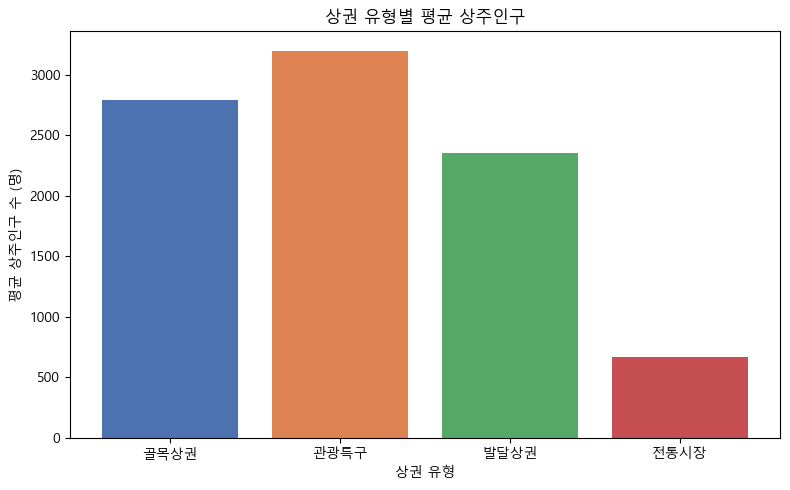

In [8]:
# 상권 유형별 총 상주인구 평균 계산
평균_상주 = df_상주.groupby('상권_구분_코드_명')['총_상주인구_수'].mean().reset_index()

# 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(평균_상주['상권_구분_코드_명'], 평균_상주['총_상주인구_수'],
       color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

ax.set_title('상권 유형별 평균 상주인구')
ax.set_xlabel('상권 유형')
ax.set_ylabel('평균 상주인구 수 (명)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 상권 유형별 평균 상주인구
- 관광특구: 약 3,200명으로 1위
- 골목상권: 약 2,800명으로 2위 → 주거 밀집 지역에 분포
- 발달상권: 약 2,350명
- 전통시장: 약 670명으로 가장 낮음
- 직장인구와 달리 유형 간 격차가 크지 않음

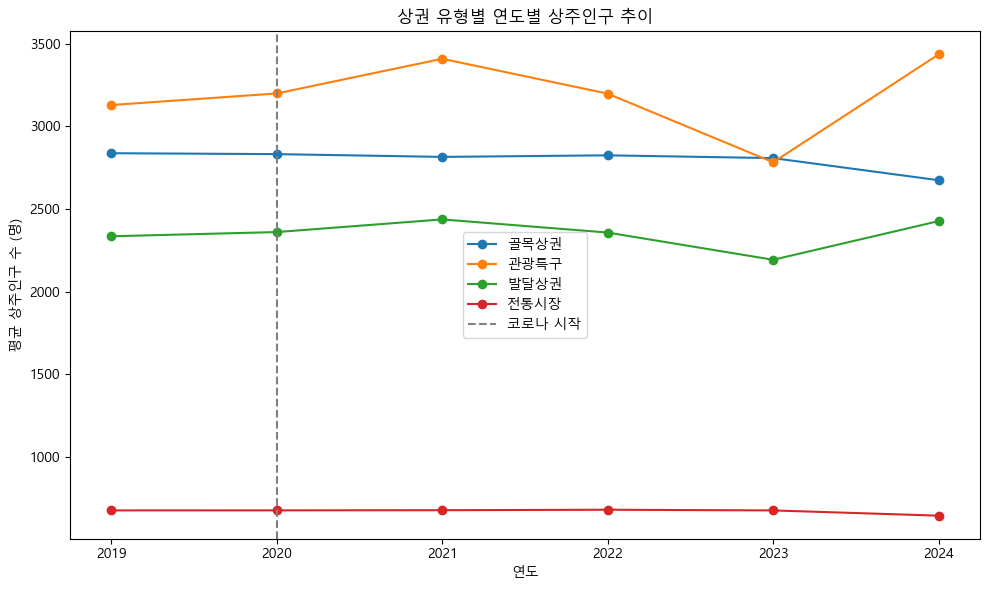

In [9]:
# 연도 컬럼 추가
df_상주['연도'] = df_상주['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 상권 유형별 연도별 평균 상주인구
연도별_상주 = df_상주.groupby(['연도', '상권_구분_코드_명'])['총_상주인구_수'].mean().reset_index()

# 꺾은선 그래프
fig, ax = plt.subplots(figsize=(10, 6))
for 유형 in 연도별_상주['상권_구분_코드_명'].unique():
    df_유형 = 연도별_상주[연도별_상주['상권_구분_코드_명'] == 유형]
    ax.plot(df_유형['연도'], df_유형['총_상주인구_수'], marker='o', label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle='--', label='코로나 시작')

ax.set_title('상권 유형별 연도별 상주인구 추이')
ax.set_xlabel('연도')
ax.set_ylabel('평균 상주인구 수 (명)')
ax.legend()
plt.tight_layout()
plt.show()

## 상권 유형별 연도별 상주인구 추이
- 관광특구: 등락 있으나 전반적으로 가장 높음
- 골목상권: 전체 기간 안정적 유지 → 주거 기반 탄탄
- 발달상권: 2023년 하락 후 2024년 회복
- 전통시장: 전체 기간 가장 낮고 변화 거의 없음
- 상주인구는 직장인구와 달리 코로나 영향 거의 없음